# 03 Improved CNN Model

Improved CNN experiment for handwritten Chinese character recognition.


In [1]:
from google.colab import drive

# Mount Google Drive to access dataset files and save experiment results
drive.mount("/content/drive")


Mounted at /content/drive


## Import Libraries


In [2]:
import json
import pickle
import time
import copy
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tqdm import tqdm


## Load Metadata and Cross-Validation Folds


In [3]:
METADATA_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246_metadata.json")
FOLDS_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246_5folds.pkl")

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

with open(FOLDS_PATH, "rb") as file:
    folds = pickle.load(file)

NUM_CLASSES = metadata["number_of_classes"]
IMAGE_SIZE = metadata.get("image_size", 64)
BATCH_SIZE = metadata.get("batch_size", 64)

class_to_idx = metadata["class_to_idx"]
idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of folds:", len(folds))


Number of classes: 246
Image size: 64
Batch size: 64
Number of folds: 5


## Dataset Paths and Optional Extraction


In [4]:
ZIP_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246.zip")

DATASET_DIR = Path("/content/CASIA_246")
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

def fix_zip_filename(filename):
    # Fix filenames stored as UTF-8 but read as cp437
    try:
        return filename.encode("cp437").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return filename

if not DATASET_DIR.exists():
    print("Dataset folder was not found. Extracting archive...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        for file_info in zip_ref.infolist():
            fixed_name = fix_zip_filename(file_info.filename)
            target_path = Path("/content") / fixed_name

            if file_info.is_dir():
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)

                with zip_ref.open(file_info) as source:
                    with open(target_path, "wb") as target:
                        target.write(source.read())

    print("Dataset extracted.")
else:
    print("Dataset already exists.")

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

print("Dataset directory:", DATASET_DIR)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)


Dataset folder was not found. Extracting archive...
Dataset extracted.
Dataset directory: /content/CASIA_246
Train directory: /content/CASIA_246/train
Test directory: /content/CASIA_246/test


## Define Image Transformations


In [5]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Light augmentation keeps character shapes readable
    transforms.RandomRotation(degrees=5, fill=255),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.95, 1.05),
        shear=3,
        fill=255
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])


## Create PyTorch Datasets


In [6]:
train_dataset_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

train_dataset_plain = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

print("Training folder samples:", len(train_dataset_augmented))
print("Test folder samples:", len(test_dataset))
print("Number of classes:", len(train_dataset_augmented.classes))

assert len(train_dataset_augmented.classes) == NUM_CLASSES
assert train_dataset_augmented.class_to_idx == test_dataset.class_to_idx
assert train_dataset_augmented.class_to_idx == class_to_idx

print("Class mapping is consistent.")


Training folder samples: 147265
Test folder samples: 35108
Number of classes: 246
Class mapping is consistent.


## DataLoader Helper for Cross-Validation


In [7]:
def create_fold_dataloaders(fold_index):
    train_indices, validation_indices = folds[fold_index]

    fold_train_dataset = Subset(train_dataset_augmented, train_indices)
    fold_validation_dataset = Subset(train_dataset_plain, validation_indices)

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    fold_validation_loader = DataLoader(
        fold_validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

for fold_index in range(len(folds)):
    fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset = create_fold_dataloaders(fold_index)

    print(
        f"Fold {fold_index + 1}: "
        f"train samples = {len(fold_train_dataset)}, "
        f"validation samples = {len(fold_validation_dataset)}, "
        f"train batches = {len(fold_train_loader)}, "
        f"validation batches = {len(fold_validation_loader)}"
    )

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))


Fold 1: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 2: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 3: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 4: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 5: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Test samples: 35108
Test batches: 549


## Utility Functions


In [8]:
def set_seed(seed=42):
    # Fix random seeds for reproducible experiments
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def count_parameters(model):
    # Count only trainable parameters
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def calculate_model_size_mb(model):
    # Estimate model size from parameters and buffers
    size_bytes = 0

    for parameter in model.parameters():
        size_bytes += parameter.numel() * parameter.element_size()

    for buffer in model.buffers():
        size_bytes += buffer.numel() * buffer.element_size()

    return size_bytes / (1024 ** 2)


def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += batch_size

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        current_loss = running_loss / total_samples
        current_accuracy = correct_predictions / total_samples

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_accuracy:.4f}"
        })

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Evaluation", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)

            correct_predictions += (predictions == labels).sum().item()
            total_samples += batch_size

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_loss = running_loss / total_samples
            current_accuracy = correct_predictions / total_samples

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_accuracy:.4f}"
            })

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def train_model(model, train_loader, validation_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_model_weights = copy.deepcopy(model.state_dict())
    best_validation_accuracy = 0.0
    best_validation_f1 = 0.0

    history = []
    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_accuracy, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        validation_loss, validation_accuracy, validation_f1 = evaluate_model(
            model, validation_loader, criterion, device
        )

        scheduler.step(validation_accuracy)

        epoch_time = time.time() - epoch_start_time
        current_lr = optimizer.param_groups[0]["lr"]

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_validation_f1 = validation_f1
            best_model_weights = copy.deepcopy(model.state_dict())

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
            "train_accuracy": train_accuracy,
            "validation_accuracy": validation_accuracy,
            "train_f1": train_f1,
            "validation_f1": validation_f1,
            "learning_rate": current_lr,
            "epoch_time": epoch_time
        })

        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={validation_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_acc={validation_accuracy:.4f} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1={validation_f1:.4f} | "
            f"lr={current_lr:.6f} | "
            f"time={epoch_time:.1f}s"
        )

    total_training_time = time.time() - total_start_time

    model.load_state_dict(best_model_weights)
    history_df = pd.DataFrame(history)

    return model, history_df, best_validation_accuracy, best_validation_f1, total_training_time


def get_predictions(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Collecting predictions"):
            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu()

            all_labels.append(labels)
            all_predictions.append(predictions)

    all_labels = torch.cat(all_labels)
    all_predictions = torch.cat(all_predictions)

    return all_labels, all_predictions


## Improved CNN Model


In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate):
        super(ConvBlock, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),

            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout_rate)
        )

    def forward(self, x):
        return self.block(x)


class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            ConvBlock(1, 32, dropout_rate=0.05),
            ConvBlock(32, 64, dropout_rate=0.10),
            ConvBlock(64, 128, dropout_rate=0.15),
            ConvBlock(128, 256, dropout_rate=0.20),
            ConvBlock(256, 384, dropout_rate=0.25),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(384, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(inplace=True),
            nn.Dropout(0.40),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.SiLU(inplace=True),
            nn.Dropout(0.30),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Model Summary


In [10]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

improved_cnn = ImprovedCNN(num_classes=NUM_CLASSES).to(device)

print(improved_cnn)

num_parameters = count_parameters(improved_cnn)
model_size_mb = calculate_model_size_mb(improved_cnn)

print("\nTrainable parameters:", num_parameters)
print("Estimated model size:", round(model_size_mb, 2), "MB")

sample_train_loader, _, _, _ = create_fold_dataloaders(0)

images, labels = next(iter(sample_train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = improved_cnn(images)

print("\nInput shape:", images.shape)
print("Output shape:", outputs.shape)


Device: cuda
ImprovedCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SiLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 

## Train Improved CNN with 5-Fold Cross-Validation


In [12]:
EPOCHS = 10
LEARNING_RATE = 0.001

BASE_OUTPUT_DIR = Path("/content/drive/MyDrive/Diploma/diploma_hccr")

MODELS_DIR = BASE_OUTPUT_DIR / "models"
HISTORIES_DIR = BASE_OUTPUT_DIR / "histories"
RESULTS_DIR = BASE_OUTPUT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
HISTORIES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fold_summaries = []
all_histories = []

best_overall_accuracy = 0.0
best_overall_f1 = 0.0
best_overall_fold = None
best_overall_model_state = None

cross_validation_start_time = time.time()

for fold_index in range(len(folds)):
    print("\n" + "=" * 60)
    print(f"Fold {fold_index + 1}/{len(folds)}")
    print("=" * 60)

    set_seed(42 + fold_index)

    fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset = create_fold_dataloaders(fold_index)

    model = ImprovedCNN(num_classes=NUM_CLASSES).to(device)

    model, fold_history_df, best_validation_accuracy, best_validation_f1, fold_training_time = train_model(
        model=model,
        train_loader=fold_train_loader,
        validation_loader=fold_validation_loader,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        device=device
    )

    fold_history_df["fold"] = fold_index + 1
    all_histories.append(fold_history_df)

    fold_model_path = MODELS_DIR / f"improved_cnn_fold_{fold_index + 1}.pth"

    torch.save({
        "model_name": "ImprovedCNN",
        "fold": fold_index + 1,
        "model_state_dict": model.state_dict(),
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "class_to_idx": train_dataset_augmented.class_to_idx,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_f1": best_validation_f1
    }, fold_model_path)

    fold_summaries.append({
        "model_name": "ImprovedCNN",
        "fold": fold_index + 1,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_f1": best_validation_f1,
        "training_time": fold_training_time,
        "average_epoch_time": fold_history_df["epoch_time"].mean(),
        "model_path": str(fold_model_path)
    })

    print(f"Fold {fold_index + 1} best validation accuracy: {best_validation_accuracy:.4f}")
    print(f"Fold {fold_index + 1} best validation macro F1-score: {best_validation_f1:.4f}")
    print(f"Fold {fold_index + 1} training time: {fold_training_time / 60:.2f} minutes")

    if best_validation_accuracy > best_overall_accuracy:
        best_overall_accuracy = best_validation_accuracy
        best_overall_f1 = best_validation_f1
        best_overall_fold = fold_index + 1
        best_overall_model_state = copy.deepcopy(model.state_dict())

total_training_time = time.time() - cross_validation_start_time

history_df = pd.concat(all_histories, ignore_index=True)
cv_summary_df = pd.DataFrame(fold_summaries)

print("\nCross-validation complete.")
print("Best fold:", best_overall_fold)
print("Best validation accuracy:", round(best_overall_accuracy, 4))
print("Best validation macro F1-score:", round(best_overall_f1, 4))
print("Total cross-validation time:", round(total_training_time, 2), "seconds")
print("Total cross-validation time:", round(total_training_time / 60, 2), "minutes")

print("\nMean validation accuracy:", round(cv_summary_df["best_validation_accuracy"].mean(), 4))
print("Std validation accuracy:", round(cv_summary_df["best_validation_accuracy"].std(), 4))
print("Mean validation macro F1-score:", round(cv_summary_df["best_validation_f1"].mean(), 4))
print("Std validation macro F1-score:", round(cv_summary_df["best_validation_f1"].std(), 4))



Fold 1/5

Epoch 1/10


train_loss=2.0636 | val_loss=0.4247 | train_acc=0.4933 | val_acc=0.8817 | train_f1=0.4928 | val_f1=0.8807 | lr=0.001000 | time=143.4s

Epoch 2/10


train_loss=0.5653 | val_loss=0.2246 | train_acc=0.8389 | val_acc=0.9381 | train_f1=0.8387 | val_f1=0.9381 | lr=0.001000 | time=135.7s

Epoch 3/10


train_loss=0.3780 | val_loss=0.1652 | train_acc=0.8919 | val_acc=0.9548 | train_f1=0.8919 | val_f1=0.9547 | lr=0.001000 | time=135.2s

Epoch 4/10


train_loss=0.2918 | val_loss=0.1436 | train_acc=0.9158 | val_acc=0.9619 | train_f1=0.9158 | val_f1=0.9620 | lr=0.001000 | time=136.1s

Epoch 5/10


...

train_loss=0.2045 | val_loss=0.1201 | train_acc=0.9411 | val_acc=0.9664 | train_f1=0.9411 | val_f1=0.9665 | lr=0.001000 | time=128.6s

Epoch 7/10


train_loss=0.1777 | val_loss=0.1176 | train_acc=0.9484 | val_acc=0.9692 | train_f1=0.9484 | val_f1=0.9693 | lr=0.001000 | time=129.8s

Epoch 8/10


train_loss=0.1605 | val_loss=0.1035 | train_acc=0.9530 | val_acc=0.9720 | train_f1=0.9530 | val_f1=0.9720 | lr=0.001000 | time=128.7s

Epoch 9/10


train_loss=0.1411 | val_loss=0.0971 | train_acc=0.9589 | val_acc=0.9746 | train_f1=0.9589 | val_f1=0.9746 | lr=0.001000 | time=126.8s

Epoch 10/10


train_loss=0.1276 | val_loss=0.0982 | train_acc=0.9623 | val_acc=0.9754 | train_f1=0.9623 | val_f1=0.9754 | lr=0.001000 | time=128.3s
Fold 5 best validation accuracy: 0.9754
Fold 5 best validation macro F1-score: 0.9754
Fold 5 training time: 21.51 minutes

Cross-validation complete.
Best fold: 5
Best validation accuracy: 0.9754
Best validation macro F1-score: 0.9754
Total cross-validation time: 6546.62 seconds
Total cross-validation time: 109.11 minutes

Mean validation accuracy: 0.9741
Std validation accuracy: 0.0007
Mean validation macro F1-score: 0.9742
Std validation macro F1-score: 0.0007


## Save Cross-Validation Results


In [13]:
BEST_MODEL_PATH = MODELS_DIR / "improved_cnn.pth"
HISTORY_PATH = HISTORIES_DIR / "improved_cnn_history.csv"
CV_SUMMARY_PATH = RESULTS_DIR / "improved_cnn_cross_validation_summary.csv"

torch.save({
    "model_name": "ImprovedCNN",
    "best_fold": best_overall_fold,
    "model_state_dict": best_overall_model_state,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "class_to_idx": train_dataset_augmented.class_to_idx,
    "best_validation_accuracy": best_overall_accuracy,
    "best_validation_f1": best_overall_f1
}, BEST_MODEL_PATH)

history_df.to_csv(HISTORY_PATH, index=False)
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False)

print("Best model saved to:", BEST_MODEL_PATH)
print("Full history saved to:", HISTORY_PATH)
print("Cross-validation summary saved to:", CV_SUMMARY_PATH)

cv_summary_df


Best model saved to: /content/drive/MyDrive/Diploma/diploma_hccr/models/improved_cnn.pth
Full history saved to: /content/drive/MyDrive/Diploma/diploma_hccr/histories/improved_cnn_history.csv
Cross-validation summary saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/improved_cnn_cross_validation_summary.csv


,model_name,fold,best_validation_accuracy,best_validation_f1,training_time,average_epoch_time,model_path
0,ImprovedCNN,1,0.973857,0.973857,1349.372057,134.931398,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
1,ImprovedCNN,2,0.973585,0.973623,1306.118963,130.606304,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
2,ImprovedCNN,3,0.974332,0.974369,1312.790058,131.272691,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
3,ImprovedCNN,4,0.973585,0.973630,1287.011993,128.695561,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
4,ImprovedCNN,5,0.975351,0.975350,1290.599437,129.053436,/content/drive/MyDrive/Diploma/diploma_hccr/mo...


## Visualize Cross-Validation Training History


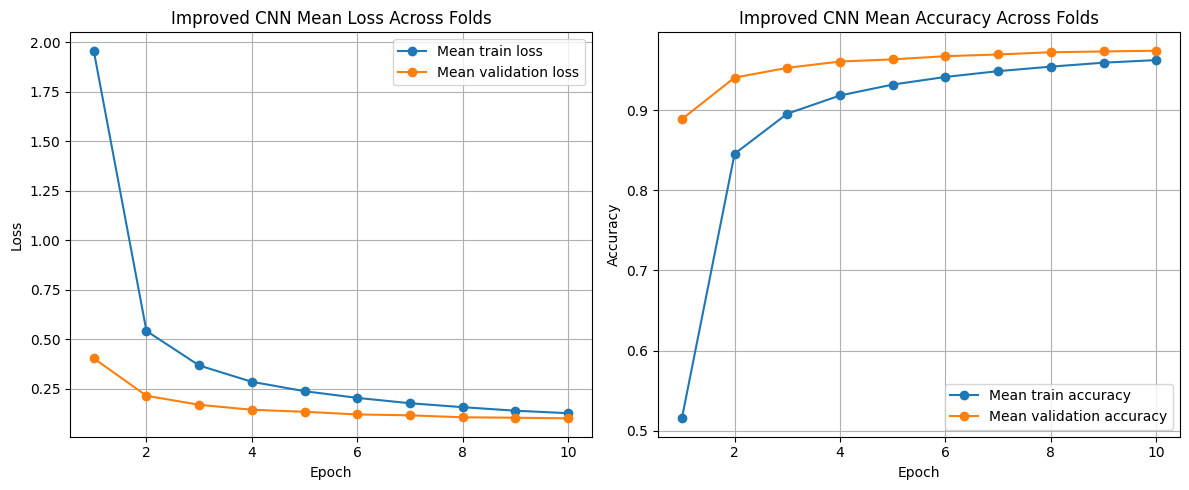

Training curves saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/improved_cnn_training_curves.png


In [14]:
mean_history = history_df.groupby("epoch").agg({
    "train_loss": "mean",
    "validation_loss": "mean",
    "train_accuracy": "mean",
    "validation_accuracy": "mean",
    "train_f1": "mean",
    "validation_f1": "mean"
}).reset_index()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mean_history["epoch"], mean_history["train_loss"], marker="o", label="Mean train loss")
plt.plot(mean_history["epoch"], mean_history["validation_loss"], marker="o", label="Mean validation loss")
plt.title("Improved CNN Mean Loss Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mean_history["epoch"], mean_history["train_accuracy"], marker="o", label="Mean train accuracy")
plt.plot(mean_history["epoch"], mean_history["validation_accuracy"], marker="o", label="Mean validation accuracy")
plt.title("Improved CNN Mean Accuracy Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

TRAINING_CURVES_PATH = FIGURES_DIR / "improved_cnn_training_curves.png"
plt.savefig(TRAINING_CURVES_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Training curves saved to:", TRAINING_CURVES_PATH)


## Load Best Cross-Validation Model


In [15]:
improved_cnn = ImprovedCNN(num_classes=NUM_CLASSES).to(device)
improved_cnn.load_state_dict(best_overall_model_state)

print("Loaded best model from fold:", best_overall_fold)

Loaded best model from fold: 5


## Evaluate Improved CNN on Test Set


In [16]:
criterion = nn.CrossEntropyLoss()

test_loss, test_accuracy, test_f1 = evaluate_model(
    model=improved_cnn,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1-score:", round(test_f1, 4))


Test loss: 0.14
Test accuracy: 0.966
Test macro F1-score: 0.966


## Save Final Summary


In [17]:
average_epoch_time = history_df["epoch_time"].mean()

summary = pd.DataFrame([{
    "model_name": "ImprovedCNN",
    "best_fold": best_overall_fold,
    "best_validation_accuracy": best_overall_accuracy,
    "best_validation_f1": best_overall_f1,
    "mean_validation_accuracy": cv_summary_df["best_validation_accuracy"].mean(),
    "std_validation_accuracy": cv_summary_df["best_validation_accuracy"].std(),
    "mean_validation_f1": cv_summary_df["best_validation_f1"].mean(),
    "std_validation_f1": cv_summary_df["best_validation_f1"].std(),
    "test_accuracy": test_accuracy,
    "test_f1": test_f1,
    "number_of_parameters": num_parameters,
    "model_size_mb": model_size_mb,
    "total_training_time": total_training_time,
    "average_epoch_time": average_epoch_time
}])

SUMMARY_PATH = RESULTS_DIR / "improved_cnn_summary.csv"

summary.to_csv(SUMMARY_PATH, index=False)

print("Summary saved to:", SUMMARY_PATH)
summary

Summary saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/improved_cnn_summary.csv


,model_name,best_fold,best_validation_accuracy,best_validation_f1,mean_validation_accuracy,std_validation_accuracy,mean_validation_f1,std_validation_f1,test_accuracy,test_f1,number_of_parameters,model_size_mb,total_training_time,average_epoch_time
0,ImprovedCNN,5,0.975351,0.97535,0.974142,0.000741,0.974166,0.000728,0.965991,0.966045,3779222,14.433762,6546.621068,130.911878


## Install Chinese Font for Prediction Visualization


In [18]:
# Install a font that supports Chinese characters
!apt-get -qq install fonts-noto-cjk

Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [19]:
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
chinese_font = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False


## Visualize Random Test Predictions


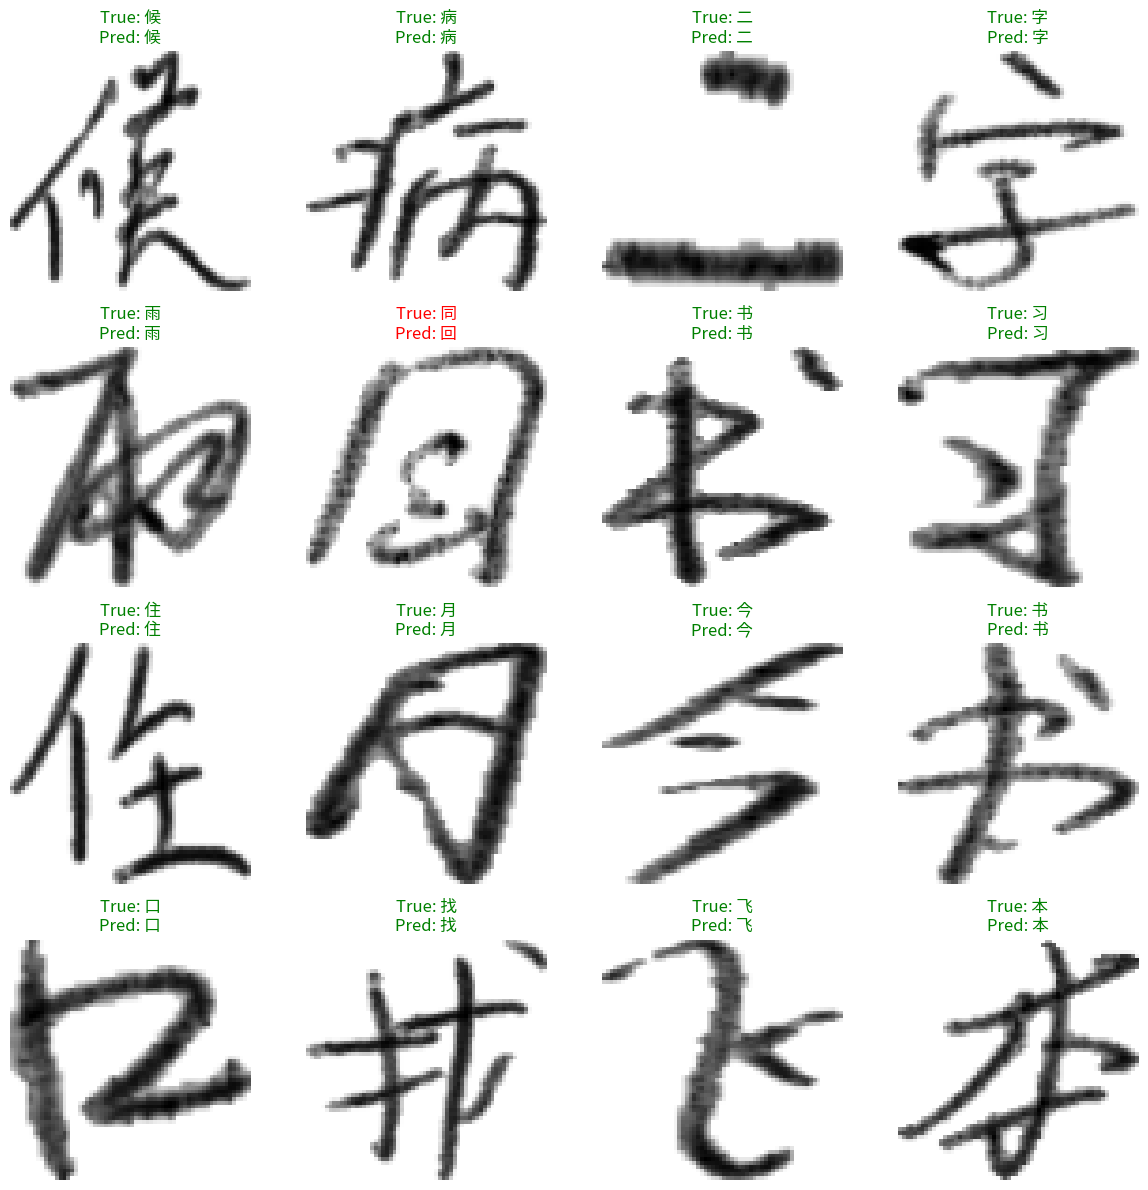

Prediction figure saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/improved_cnn_random_test_predictions.png


In [20]:
test_labels, test_predictions = get_predictions(
    model=improved_cnn,
    data_loader=test_loader,
    device=device
)

random_indices = random.sample(range(len(test_dataset)), 16)

plt.figure(figsize=(12, 12))

for plot_index, sample_index in enumerate(random_indices):
    image, true_index = test_dataset[sample_index]

    # Convert values back to the visible range
    image = image.squeeze(0)
    image = image * 0.5 + 0.5

    predicted_index = test_predictions[sample_index].item()

    true_label = idx_to_class[true_index]
    predicted_label = idx_to_class[predicted_index]

    title_color = "green" if true_index == predicted_index else "red"

    plt.subplot(4, 4, plot_index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontproperties=chinese_font,
        fontsize=12,
        color=title_color
    )
    plt.axis("off")

plt.tight_layout()

PREDICTIONS_FIGURE_PATH = FIGURES_DIR / "improved_cnn_random_test_predictions.png"
plt.savefig(PREDICTIONS_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Prediction figure saved to:", PREDICTIONS_FIGURE_PATH)


The Improved CNN experiment is complete. The trained model, training history, training curves, test summary, and prediction visualization were saved to Google Drive.
